# 철강 표면 결함 분류 — Baseline

96×96 흑백 이미지에서 열연 강판의 표면 결함 6종 분류


## 1. 환경 설정

In [1]:
import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


## 2. 데이터 소개

**NEU Surface Defect Database**의 이미지 분류용 데이터

- 대상: 열연 강판 표면
- 원본: 200×200 흑백 이미지
- 모델 입력: 96×96 흑백 이미지
- 정답: 표면 결함 6종
- 샘플: 클래스당 300장, 총 1,800장
- 분할: Train 1,440 / Validation 180 / Test 180

| 클래스 | 의미 |
|---|---|
| `crazing` | 미세 균열망 |
| `inclusion` | 개재물 |
| `patches` | 불규칙 반점 |
| `pitted_surface` | 점식·패임 표면 |
| `rolled-in_scale` | 압입 산화피막 |
| `scratches` | 긁힘 |

> 출처: Northeastern University의 NEU 표면 결함 데이터. Kaggle 배포본은 라이선스가 명시되지 않아 교육 목적으로 사용합니다. [데이터 설명](https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database)


### 폴더 구조

KaggleHub로 원본 데이터 자동 다운로드

```text
NEU-DET/
├── train/images/클래스명/*.jpg
└── validation/images/클래스명/*.jpg
```

- `train`: 학습 데이터
- `validation`: 클래스별 30장은 검증, 30장은 테스트에 사용
- `annotations`: 객체탐지용 XML이므로 이번 분류 실습에서는 제외


## 3. 데이터 불러오기

In [2]:
path = kagglehub.dataset_download(
    "kaustubhdikshit/neu-surface-defect-database"
)

data_root = Path(path) / "NEU-DET"
train_root = data_root / "train" / "images"
heldout_root = data_root / "validation" / "images"

class_names = sorted(folder.name for folder in train_root.iterdir() if folder.is_dir())
rng = np.random.default_rng(SEED)

train_samples = []
val_samples = []
test_samples = []

for class_id, class_name in enumerate(class_names):
    train_files = sorted((train_root / class_name).glob("*.jpg"))
    heldout_files = sorted((heldout_root / class_name).glob("*.jpg"))
    order = rng.permutation(len(heldout_files))

    val_files = [heldout_files[i] for i in order[:30]]
    test_files = [heldout_files[i] for i in order[30:]]

    train_samples.extend((file, class_id) for file in train_files)
    val_samples.extend((file, class_id) for file in val_files)
    test_samples.extend((file, class_id) for file in test_files)

print("data path:", data_root)
print("classes  :", class_names)
print("split    :", len(train_samples), len(val_samples), len(test_samples))


data path: /Users/han/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1/NEU-DET
classes  : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
split    : 1440 180 180


### 클래스별 이미지

In [3]:
plt.figure(figsize=(12, 6))

for class_id, class_name in enumerate(class_names):
    examples = [file for file, label in train_samples if label == class_id][:2]

    for column, file in enumerate(examples):
        plot_index = class_id * 2 + column + 1
        plt.subplot(3, 4, plot_index)
        plt.imshow(Image.open(file).convert("L"), cmap="gray")
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 12 Axes>

## 4. Dataset과 DataLoader

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])


class SteelDefectDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file, label = self.samples[index]
        image = Image.open(file).convert("L")
        image = self.transform(image)
        return image, label


train_dataset = SteelDefectDataset(train_samples, image_transform)
val_dataset = SteelDefectDataset(val_samples, image_transform)
test_dataset = SteelDefectDataset(test_samples, image_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print("image batch:", batch_images.shape)
print("label batch:", batch_labels.shape)


image batch: torch.Size([64, 1, 96, 96])
label batch: torch.Size([64])


## 5.1 수정 모델
1. Convolution Layer 추가

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Convolutional Block 1개를 추가해 채널 수를 8에서 16으로 확장합니다.
            nn.Conv2d(8, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 21 * 21, 32),
            nn.ReLU(),
            nn.Linear(32, 6),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = BaselineCNN().to(device)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7056, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=6, bias=True)
  )
)
parameters: 229,446


## 6. 손실 함수와 옵티마이저

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 7. 학습

In [7]:
def run_epoch(model, loader, training=False):
    model.train() if training else model.eval()
    total_loss = 0.0
    correct = 0
    count = 0

    with torch.set_grad_enabled(training):
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            predictions = model(batch_images)
            loss = loss_fn(predictions, batch_labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(batch_images)
            correct += (predictions.argmax(1) == batch_labels).sum().item()
            count += len(batch_images)

    return total_loss / count, correct / count

In [8]:
EPOCHS = 15
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_weights = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, training=True)
    val_loss, val_acc = run_epoch(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d} | "
        f"train {train_loss:.3f}, {train_acc:.3f} | "
        f"val {val_loss:.3f}, {val_acc:.3f}"
    )

model.load_state_dict(best_weights)

Epoch 01 | train 1.744, 0.241 | val 1.699, 0.322
Epoch 02 | train 1.584, 0.356 | val 1.686, 0.328
Epoch 03 | train 1.330, 0.537 | val 1.455, 0.406
Epoch 04 | train 1.094, 0.659 | val 1.440, 0.417
Epoch 05 | train 0.915, 0.716 | val 1.234, 0.511
Epoch 06 | train 0.758, 0.781 | val 1.126, 0.544
Epoch 07 | train 0.693, 0.784 | val 1.045, 0.611
Epoch 08 | train 0.625, 0.798 | val 1.035, 0.600
Epoch 09 | train 0.586, 0.812 | val 0.929, 0.644
Epoch 10 | train 0.522, 0.830 | val 0.971, 0.611
Epoch 11 | train 0.524, 0.824 | val 1.174, 0.567
Epoch 12 | train 0.462, 0.853 | val 0.917, 0.689
Epoch 13 | train 0.435, 0.863 | val 0.777, 0.667
Epoch 14 | train 0.418, 0.868 | val 0.927, 0.661
Epoch 15 | train 0.431, 0.862 | val 0.734, 0.728


<All keys matched successfully>

## 8. 학습 곡선

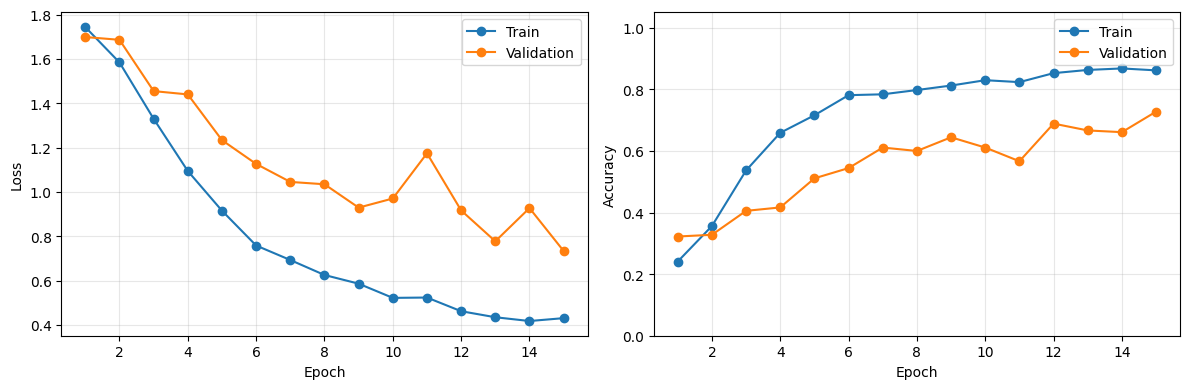

In [9]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Validation 성능


In [10]:
def predict(model, loader):
    model.eval()
    answers = []
    predictions = []

    with torch.no_grad():
        for batch_images, batch_labels in loader:
            outputs = model(batch_images.to(device))
            predictions.extend(outputs.argmax(1).cpu().numpy())
            answers.extend(batch_labels.numpy())

    return np.asarray(answers), np.asarray(predictions)


val_answers, val_predictions = predict(model, val_loader)
val_accuracy = accuracy_score(val_answers, val_predictions)
val_f1 = f1_score(val_answers, val_predictions, average="macro")

print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Validation Macro F1: {val_f1:.3f}")

Validation Accuracy: 0.728
Validation Macro F1: 0.721


### 혼동행렬

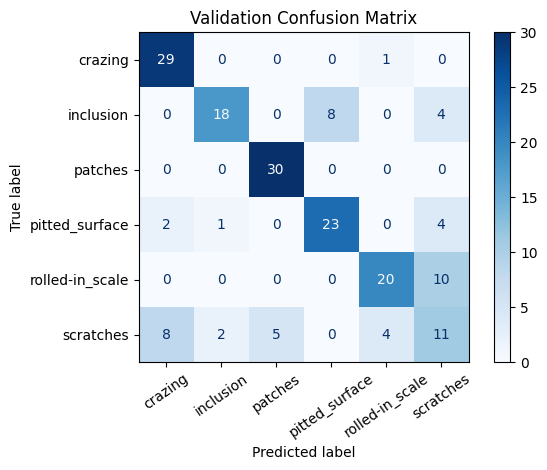

In [11]:
ConfusionMatrixDisplay.from_predictions(
    val_answers,
    val_predictions,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=35,
)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Validation 예측 결과


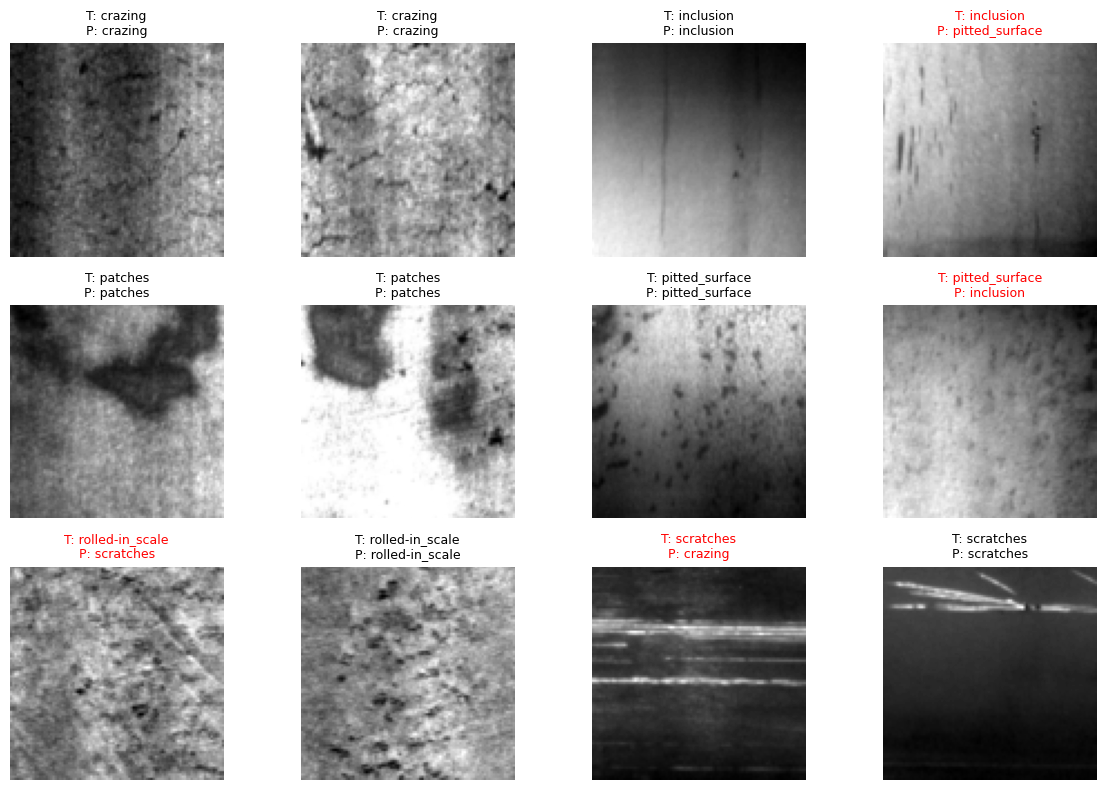

In [12]:
plt.figure(figsize=(12, 8))

sample_indices = []
for class_id in range(len(class_names)):
    indices = [i for i, (_, label) in enumerate(val_samples) if label == class_id]
    sample_indices.extend(indices[:2])

for plot_index, data_index in enumerate(sample_indices, start=1):
    image, answer = val_dataset[data_index]

    with torch.no_grad():
        prediction = model(image.unsqueeze(0).to(device)).argmax(1).item()

    color = "black" if prediction == answer else "red"

    plt.subplot(3, 4, plot_index)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"T: {class_names[answer]}\nP: {class_names[prediction]}",
        color=color,
        fontsize=9,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 11. Feature map

Feature map: 합성곱 필터의 반응 결과


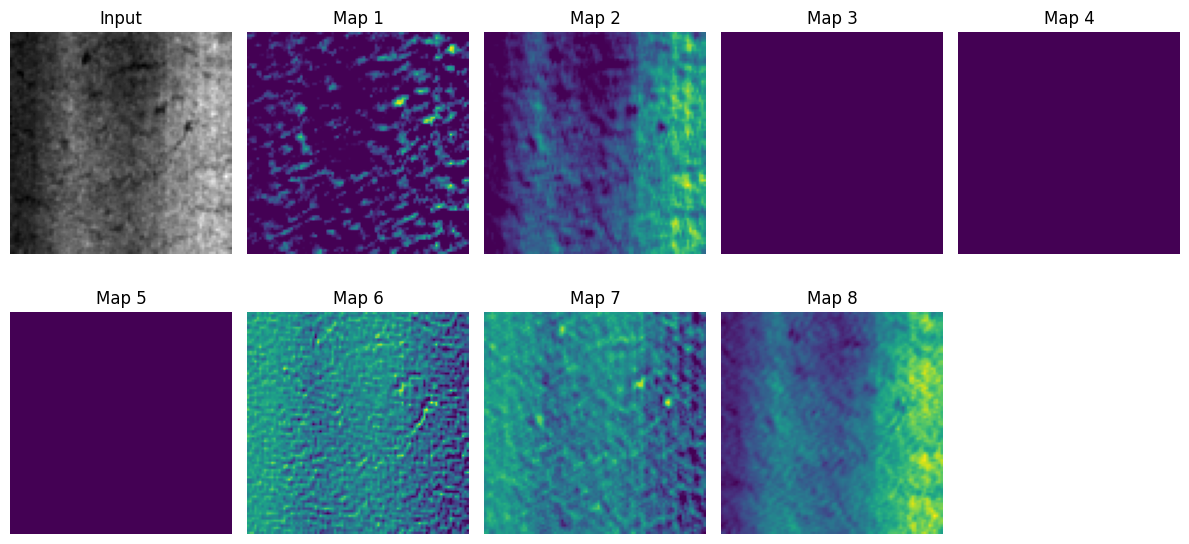

In [13]:
def show_feature_maps(model, layer, image, max_maps=8):
    activation = {}

    def save_output(module, inputs, output):
        activation["maps"] = output.detach().cpu()

    hook = layer.register_forward_hook(save_output)

    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    hook.remove()

    maps = activation["maps"][0]
    count = min(max_maps, len(maps))

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 5, 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    for i in range(count):
        plt.subplot(2, 5, i + 2)
        plt.imshow(maps[i], cmap="viridis")
        plt.title(f"Map {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# 첫 번째 Convolutional Block의 ReLU Activation Map을 시각화합니다.
sample_image, _ = val_dataset[0]
show_feature_maps(model, model.features[1], sample_image)


## 12. Baseline 진단

다음 항목을 확인하고 종합실습의 최적화 목표를 정한다.

1. Train과 Validation 성능 차이에서 어떤 문제가 보이는가?
2. 가장 많이 혼동하는 클래스와 오분류 이미지의 특징은 무엇인가?
3. Validation 성능과 과적합을 함께 개선하려면 무엇을 먼저 변경할 것인가?
4. 변경 결과를 어떤 지표로 판단할 것인가?

> 별도 답안은 제출하지 않으며, 분석 결과를 종합실습 보고서의 `Baseline 진단`에 반영한다.
